In [1]:
%load_ext autoreload
%autoreload 2

In [15]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import torch

sys.path.append('../')
from data_prep import image


In [83]:
segment = torch.tensor([[10.2,12.6,30.9],
                        [13.9,13.7,21.8]])
width = 3.0

start = segment[0]
segment = segment[1] - segment[0]
if isinstance(segment, np.ndarray):
    segment = torch.from_numpy(segment)

# the patch should contain both line end points plus some blur
# L = int(torch.ceil(segment_length)) + 1 # The radius of the patch is the whole line length since the line starts at patch center.
L = int(max(abs(segment).tolist()))
overhang = int(np.ceil(2*width)) # include space beyond the end of the line
patch_radius = L + overhang
# patch_radius = 20

patch_size = 2*patch_radius + 1
x = [torch.arange(patch_size),]*3
X = torch.stack(torch.meshgrid(*x, indexing='ij'), -1)
translation = (torch.tensor([patch_radius,]*3) + (start % 1))
X = X - translation

print(X[patch_radius, patch_radius, patch_radius])


tensor([-0.2000, -0.6000, -0.9000])


In [57]:
seglen_sq = torch.dot(segment, segment)
P = torch.outer(segment, segment) / seglen_sq
P_ = (torch.eye(3) - P)

In [143]:
Q = torch.matmul(P_[None,None,None], X[...,None]).squeeze()
dist = torch.linalg.norm(Q, dim=-1)
segTb = torch.matmul(segment[None,None,None,None], X[...,None]).squeeze()
dist_to_end = torch.linalg.norm(X - segment, dim=-1)
dist_to_start = torch.linalg.norm(X, dim=-1)
dist = torch.where(segTb > seglen_sq, dist_to_end, dist)
dist = torch.where(segTb < 0, dist_to_start, dist)
# seg_img = dist
width=30.0
seg_img = torch.exp(-0.5 * (dist / (width / 2.35))**2)
binary_img = dist < width / 2

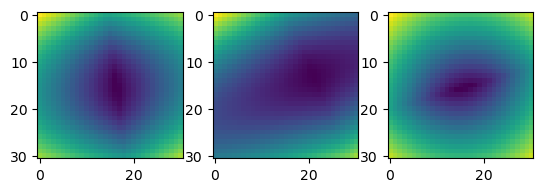

In [85]:
plt.close('all')
fig, ax = plt.subplots(1,3)

ax[0].imshow(dist.amax(0))
ax[1].imshow(dist.amax(1))
ax[2].imshow(dist.amax(2))
plt.show()

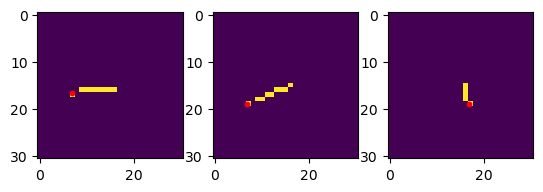

In [139]:
plt.close('all')
fig, ax = plt.subplots(1,3)
end_point = segment + translation
ax[0].imshow(binary_img.amax(0))
ax[0].scatter(end_point[2], end_point[1], c='r', s=10)
ax[1].imshow(binary_img.amax(1))
ax[1].scatter(end_point[2], end_point[0], c='r', s=10)
ax[2].imshow(binary_img.amax(2))
ax[2].scatter(end_point[1], end_point[0], c='r', s=10)
plt.show()

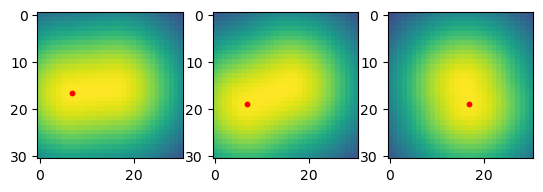

In [144]:
plt.close('all')
fig, ax = plt.subplots(1,3)
end_point = segment + translation
ax[0].imshow(seg_img.amax(0), vmin=0, vmax=1)
ax[0].scatter(end_point[2], end_point[1], c='r', s=10)
ax[1].imshow(seg_img.amax(1), vmin=0, vmax=1)
ax[1].scatter(end_point[2], end_point[0], c='r', s=10)
ax[2].imshow(seg_img.amax(2), vmin=0, vmax=1)
ax[2].scatter(end_point[1], end_point[0], c='r', s=10)
plt.show()